In [57]:
import pandas as pd
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [35]:
path = Path(R"C:\Users\mbcxamk2\OneDrive - The University of Manchester\MRI Physicist Job\Projects\Replacing Diffusion QA Phantom\Dev 4 20261001 (full + thermo)\ground_truth\O-3574 Calibration_GSP_PVP_20220331.xlsx")
df = pd.read_excel(path)

# Test showing that a quadratic fit perfectly describes temperature - relaxation relationship across all vials
- linear fails for PVP-0050 T2

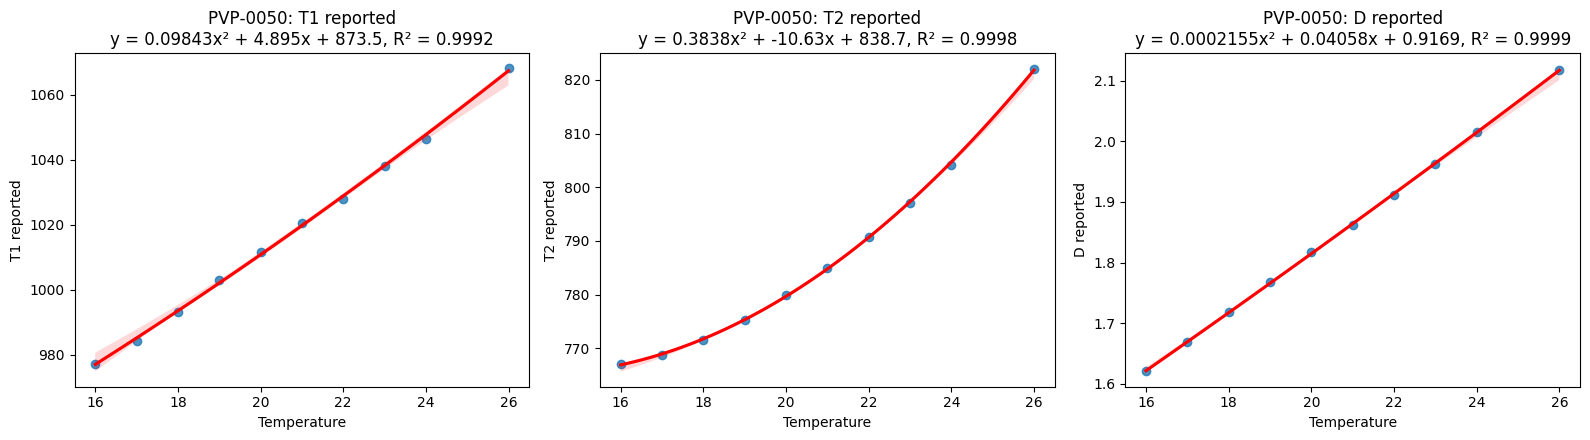

In [36]:
product = "PVP‑0050"

cols = ["T1 reported", "T2 reported", "D reported"]
sub = df[df["Order code name"] == product]
data = sub[["Temperature"] + cols].apply(pd.to_numeric, errors="coerce")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, cols):
    d = data[["Temperature", col]].dropna().iloc[1:-1]
    a, b, c = np.polyfit(d["Temperature"], d[col], 2)
    pred = np.polyval([a, b, c], d["Temperature"])
    r2 = 1 - ((d[col] - pred) ** 2).sum() / ((d[col] - d[col].mean()) ** 2).sum()
    sns.regplot(data=d, x="Temperature", y=col, ax=ax, line_kws={"color": "red"}, order = 2)
    ax.set_title(f"{product}: {col}\ny = {a:.4g}x² + {b:.4g}x + {c:.4g}, R² = {r2:.4f}")
    ax.set_xlabel("Temperature")
plt.tight_layout()
plt.show()

In [37]:
path = Path(R"C:\Users\mbcxamk2\OneDrive - The University of Manchester\MRI Physicist Job\Projects\Replacing Diffusion QA Phantom\Dev 4 20261001 (full + thermo)\ground_truth\O-41770_GoldStandPhant_GSP_T1T2_20230125.xlsx")
df = pd.read_excel(path)

Plotting MNCL‑0159 (7/13)


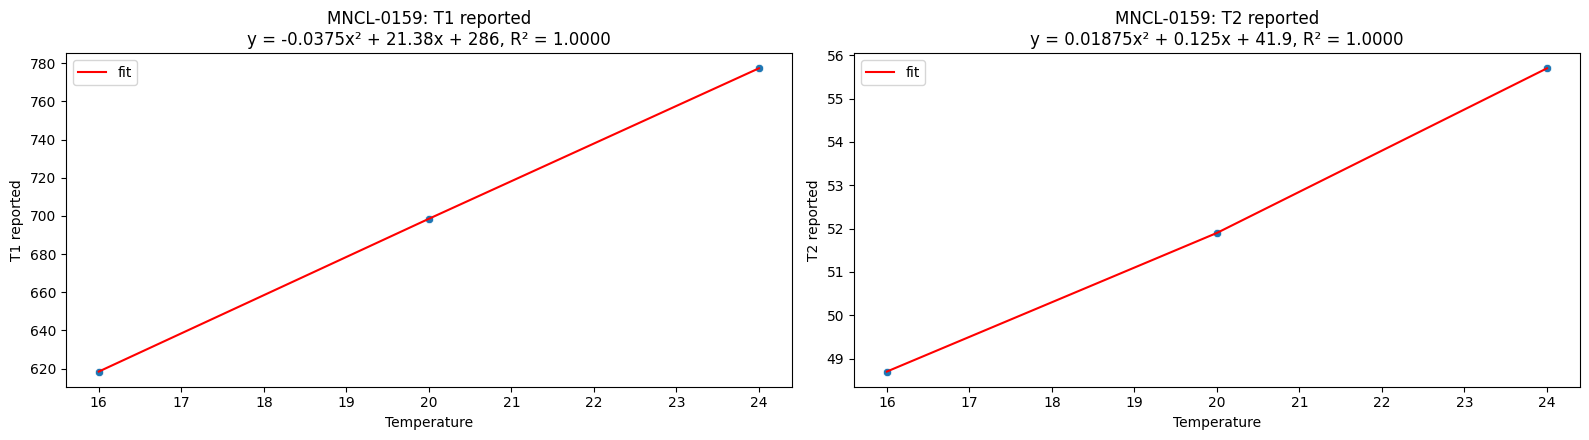

In [56]:
products = df["Order code name"].unique()
idx = 6
product = products[idx + 1]
print(f"Plotting {product} ({idx + 1}/{len(products)})")

cols = ["T1 reported", "T2 reported"]
sub = df[df["Order code name"] == product]
data = sub[["Temperature"] + cols].apply(pd.to_numeric, errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
for ax, col in zip(axes, cols):
    d = data[["Temperature", col]].dropna()
    a, b, c = np.polyfit(d["Temperature"], d[col], 2)
    pred = np.polyval([a, b, c], d["Temperature"])
    r2 = 1 - ((d[col] - pred) ** 2).sum() / ((d[col] - d[col].mean()) ** 2).sum()
    sns.scatterplot(data=d, x="Temperature", y=col, ax=ax)
    sns.lineplot(x=d["Temperature"], y=pred, sort=True, ax=ax, color="red", label="fit")
    ax.set_title(f"{product}: {col}\ny = {a:.4g}x² + {b:.4g}x + {c:.4g}, R² = {r2:.4f}")
    ax.set_xlabel("Temperature")
plt.tight_layout()
plt.show()